In [1]:
import numpy as np
import pandas as pd
import healpy as hp
import matplotlib.pyplot as plt
import rasterio
from src2.FDrule import FDrule

In [2]:
nside=32

In [3]:
df=pd.read_csv('./database/Australia.csv')
Lon=df['Longitude in degrees'].to_numpy()
Lat=df['Latitude in degrees'].to_numpy()
power=df['EIRP'].to_numpy()
frequency=df['Frequency(MHz)'].to_numpy()

In [4]:
trainpix=hp.ang2pix(nside,Lon,Lat,lonlat=True)

In [5]:
new_pix=np.random.choice(trainpix,size=500)

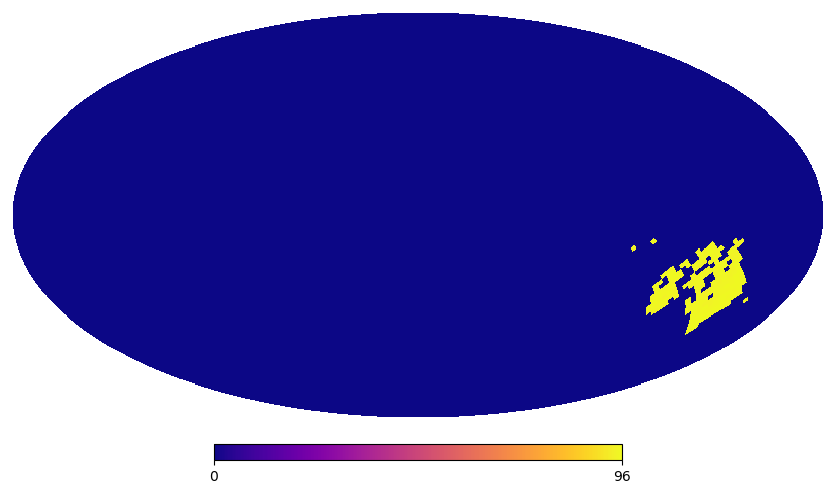

In [6]:
Tx_num_128=np.zeros(hp.nside2npix(nside))
for pix in trainpix:
    Tx_num_128[pix]+=1
hp.mollview(Tx_num_128,flip='geo',cmap='plasma',norm='hist',title='')
# plt.savefig('/home/pratush/Yogen_STARFIRE/STARFIRE_paper images/new_Txnum',dpi=600)
plt.show()

## Start 2d prob model now

In [7]:
smallon,smallat=hp.pix2ang(nside,new_pix,lonlat=True)
smallon[smallon>180]-=360

In [8]:
data=np.column_stack((smallon,smallat))

In [9]:
minres=hp.nside2resol(128,arcmin=True)

In [10]:
minres=minres/60

In [11]:
minres

0.45806485490898746

## Best bin width (Shimizaki et al.)

1
# -7.412181309246159 103 0.4641990291262133
# -7.412181309246159 72 0.46962208693161855


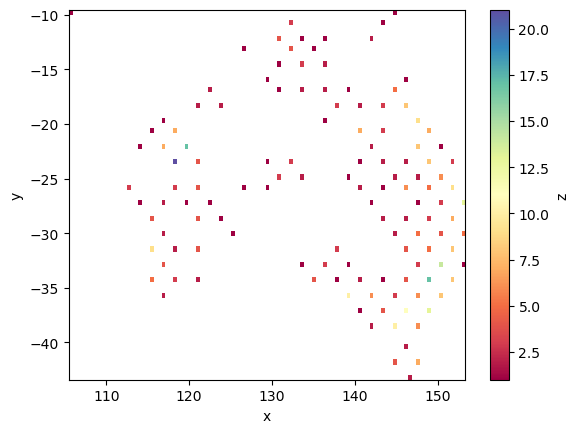

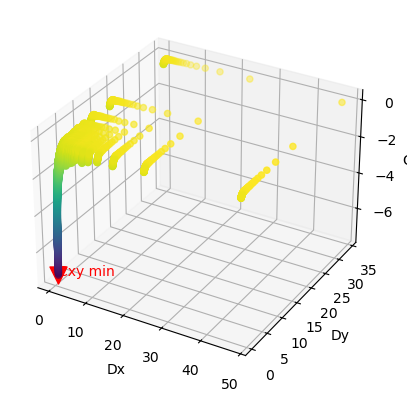

In [12]:
from numpy import arange, argmin, sum, mean, var, size, zeros, where, histogram

x = smallon 
y = smallat  

x_max = max(x)
x_min = min(x)

y_max = max(y)
y_min = min(y)

Nx_MIN = 1  # Minimum number of bins in x (integer)
Nx_MAX = int((x_max-x_min)/minres)  # Maximum number of bins in x (integer)

Ny_MIN = 1  # Minimum number of bins in y (integer)
Ny_MAX = int((y_max-y_min)/minres)  # Maximum number of bins in y (integer)

Nx = arange(Nx_MIN, Nx_MAX)  # #of Bins
Ny = arange(Ny_MIN, Ny_MAX)  # #of Bins

Dx = (x_max - x_min) / Nx  # Bin size vector
Dy = (y_max - y_min) / Ny  # Bin size vector

Dxy = []
for i in Dx:  # Bin size vector
    a = []
    for j in Dy:  # Bin size vector
        a.append((i, j))
    Dxy.append(a)
Dxy = np.array(Dxy, dtype=[('x', float), ('y', float)])  # matrix of bin size vector

Cxy = zeros(np.shape(Dxy))

Cxy__Dxy_plot = []  # save data to plot in scatterplot x,y,z

# Computation of the cost function to x and y
for i in range(size(Nx)):
    for j in range(size(Ny)):
        ki = np.histogram2d(x, y, bins=(Nx[i], Ny[j]))
        ki = ki[0]  # The mean and the variance are simply computed from the event counts in all the bins of the 2-dimensional histogram.
        k = mean(ki)  # Mean of event count
        v = var(ki)  # Variance of event count
        Cxy[i, j] = (2 * k - v) / ((Dxy[i, j][0] * Dxy[i, j][1]) ** 2)  # The cost Function

        # (Cxy      , Dx          ,  Dy)
        Cxy__Dxy_plot.append((Cxy[i, j], Dxy[i, j][0], Dxy[i, j][1]))  # Save result of cost function to scatterplot

Cxy__Dxy_plot = np.array(Cxy__Dxy_plot, dtype=[('Cxy', float), ('Dx', float), ('Dy', float)])  # Save result of cost function to scatterplot

# Optimal Bin Size Selection

# combination of i and j that produces the minimum cost function
idx_min_Cxy = np.where(Cxy == np.min(Cxy))  # get the index of the min Cxy

Cxymin = Cxy[idx_min_Cxy[0][0], idx_min_Cxy[1][0]]  # value of the min Cxy

print(sum(Cxy == Cxymin))  # check if there is only one min value

optDxy = Dxy[idx_min_Cxy[0][0], idx_min_Cxy[1][0]]  # get the bins size pairs that produces the minimum cost function

optDx = optDxy[0]
optDy = optDxy[1]

idx_Nx = idx_min_Cxy[0][0]  # get the index in x that produces the minimum cost function
idx_Ny = idx_min_Cxy[1][0]  # get the index in y that produces the minimum cost function

print('#', Cxymin, Nx[idx_Nx], optDx)
print('#', Cxymin, Ny[idx_Ny], optDy)

# PLOTS

# plot histogram2d
fig = plt.figure()
H, xedges, yedges = np.histogram2d(x, y, bins=[Nx[idx_Nx], Ny[idx_Ny]])
Hmasked = np.ma.masked_where(H == 0, H)
plt.imshow(Hmasked.T, extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]], interpolation='nearest', origin='lower', aspect='auto', cmap=plt.cm.Spectral)
plt.ylabel("y")
plt.xlabel("x")
plt.colorbar().set_label('z')
plt.show()

# plot scatterplot3d to Dx,Dy and Cxy
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
x = Cxy__Dxy_plot['Dx']
y = Cxy__Dxy_plot['Dy']
z = Cxy__Dxy_plot['Cxy']
ax.scatter(x, y, z, c=z, marker='o')

ax.set_xlabel('Dx')
ax.set_ylabel('Dy')
ax.set_zlabel('Cxy')
plt.draw()

ax.scatter([optDx], [optDy], [Cxymin], marker='v', s=150, c="red")
ax.text(optDx, optDy, Cxymin, "Cxy min", color='red')
plt.draw()
plt.show()


In [13]:
Ny_MAX-Nx[idx_Ny]

1

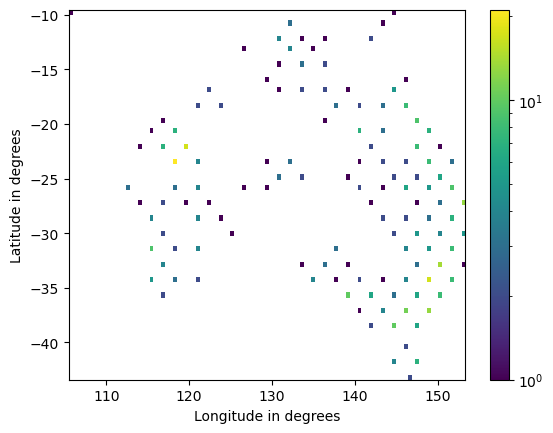

In [14]:
### from mpl_toolkits.axes_grid1 import make_axes_locatable
np.random.seed(42)


x, y = data.T
BIN_COUNT1 = Nx[idx_Nx]
BIN_COUNT2=Ny[idx_Ny]

hist, bins= np.histogramdd(data,bins=(BIN_COUNT1,BIN_COUNT2),density=True)
x_bins=bins[0]
y_bins=bins[1]
x_bin_midpoints = (x_bins[:-1] + x_bins[1:])/2
y_bin_midpoints = (y_bins[:-1] + y_bins[1:])/2

cdf = np.cumsum(hist.flatten())
cdf = cdf / cdf[-1]

# values = np.random.rand(finval)
# value_bins = np.searchsorted(cdf, values)
# x_idx, y_idx = np.unravel_index(value_bins,
#                                 (len(x_bin_midpoints),
#                                  len(y_bin_midpoints)))
# random_from_cdf = np.column_stack((x_bin_midpoints[x_idx],
#                                    y_bin_midpoints[y_idx]))
# new_x, new_y = random_from_cdf.T
plt.hist2d(x, y, bins=(BIN_COUNT1, BIN_COUNT2),norm='log')
plt.colorbar()
plt.xlabel('Longitude in degrees')
plt.ylabel('Latitude in degrees')
# plt.savefig('/home/pratush/Yogen_STARFIRE/STARFIRE_paper_images/2D_hist.pdf',dpi=600,bbox_inches='tight')
plt.show()

In [15]:
(max(x)-min(x))/BIN_COUNT1


0.4641990291262133

In [16]:
hist=hist.reshape(BIN_COUNT1,BIN_COUNT2) # reshape back for interpolation

In [17]:
from scipy.interpolate import RegularGridInterpolator
x1=x_bins[:-1]
y1=y_bins[:-1]
V=hist

fn=RegularGridInterpolator((x1,y1),V,bounds_error=False,fill_value=0)


In [18]:
# Open the GeoTIFF file
src = rasterio.open('/home/pratush/5kRasters/Australia_raster.tif')

# Read the raster data as a numpy array
data = src.read(1)  

# Find pixels with non-zero values
non_zero_pixels = np.where(data != 0)

# Get the coordinates of non zero pixels
templat=[]
templon=[]
for y, x in zip(*non_zero_pixels):
    lonval, latval = src.xy(y, x)  # Get the longitude and latitude of the pixel
    templat.append(latval)
    templon.append(lonval)


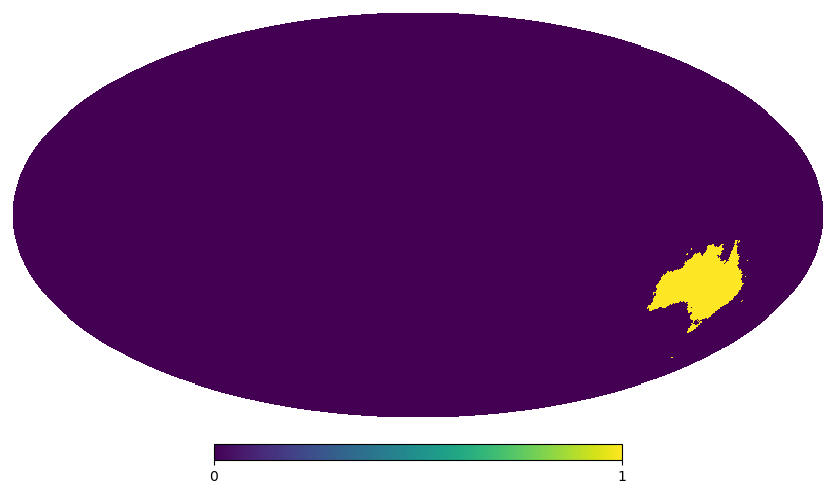

In [19]:
# country raster 
# Making a mask for generated data
temppix=hp.ang2pix(128,templon,templat,lonlat=True)
template=np.zeros(hp.nside2npix(128))
for pi in temppix:
    template[pi]+=1
template=np.where(template != 0, 1, 0)
hp.mollview(template,flip='geo',min=0,title='')
# plt.savefig('/home/pratush/Yogen_STARFIRE/STARFIRE_paper_images/Country_shp.pdf',dpi=600)

In [20]:
pop_pix=np.argwhere(template) # obtain non zero pix aka country pix
pop_pix=np.sort(pop_pix)
allon,allat=hp.pix2ang(128,pop_pix,lonlat=True)        
allon[allon>180]-=360
allon=allon.reshape(allon.shape[0])
allat=allat.reshape(allat.shape[0])

In [21]:
pop_pix.shape

(3263, 1)

In [22]:
prob_vals=[] # obtain probabilty values for each pixel of the country (represented by allon and allat)
for i in range(len(allat)):
    a=allon[i]
    b=allat[i]
    prob_vals.append(fn([a,b]))
prob_vals=np.array(prob_vals)
prob_vals=prob_vals.reshape(prob_vals.shape[0]) 

In [23]:
prob_vals=prob_vals/np.sum(prob_vals) # normalize the PDF for generating synth data

In [24]:
prob_pix=hp.ang2pix(128,allon,allat,lonlat=True)
prob_healpix=np.zeros(hp.nside2npix(128))
for index,p in enumerate(prob_pix):
    prob_healpix[p]+=(prob_vals[index])

# plt.savefig('/home/pratush/Yogen_STARFIRE/STARFIRE_paper images/new_Txpow',dpi=600)

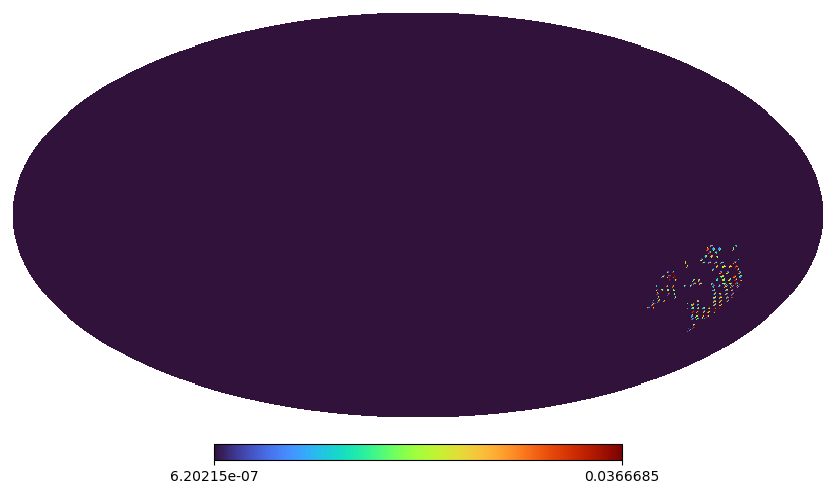

In [25]:
hp.mollview(prob_healpix,flip='geo',cmap='turbo',norm='hist',min=np.min(prob_healpix[np.nonzero(prob_healpix)]),title='')
# plt.savefig('/home/pratush/Yogen_STARFIRE/STARFIRE_paper_images/Prob_heatmap.pdf',dpi=600)#visualize PDF as a heatmap
plt.show()

In [26]:
pop_pix=pop_pix.reshape(pop_pix.shape[0]) 
#
#
#
#
genpix=np.random.choice(pop_pix,size=len(Lon),p=prob_vals)

In [27]:
genlon,genlat=hp.pix2ang(128,genpix,lonlat=True)
genlon[genlon>180]-=360

In [28]:
newdf=pd.DataFrame({'lon':genlon,'lat':genlat})
# newdf.to_csv('/home/pratush/Documents/auscheck.csv')

In [29]:
binary_original=np.zeros(hp.nside2npix(nside))

In [30]:
for i in trainpix:
    binary_original[i]+=1
binary_original=np.where(binary_original != 0, 1, 0)


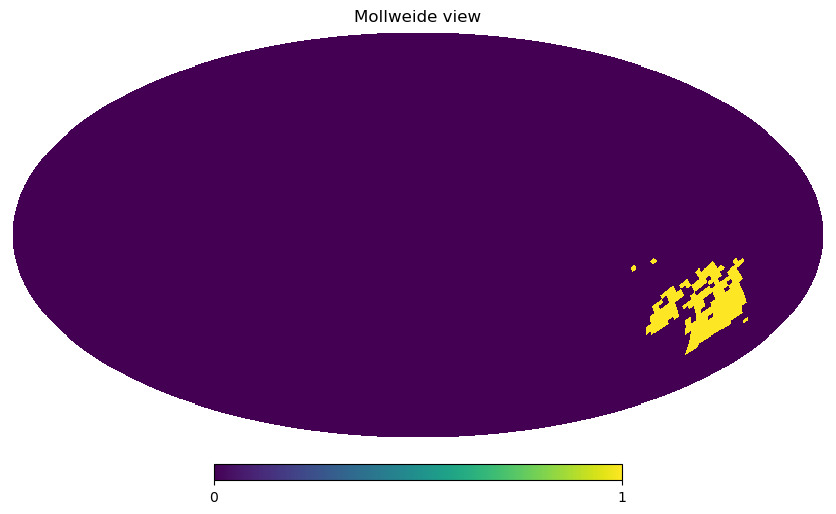

In [31]:
hp.mollview(binary_original,flip='geo')

In [32]:
binary_synth=np.zeros(hp.nside2npix(nside))


In [33]:
gen2pix=hp.ang2pix(nside,genlon,genlat,lonlat=True)
for i in gen2pix:
    binary_synth[i]+=1
binary_synth=np.where(binary_synth != 0, 1, 0)


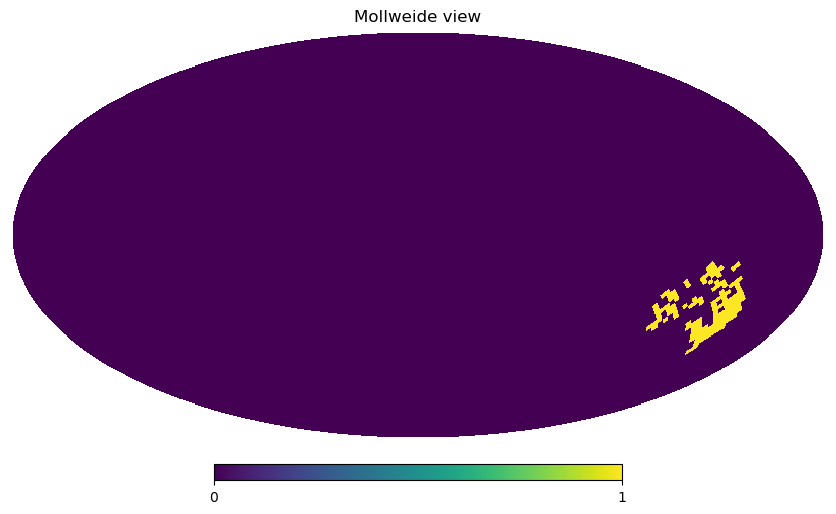

In [34]:
hp.mollview(binary_synth,flip='geo')

In [35]:
temppix2=hp.ang2pix(nside,templon,templat,lonlat=True)
template2=np.zeros(hp.nside2npix(nside))
for pi in temppix2:
    template2[pi]+=1
template2=np.where(template2 != 0, 1, 0)

In [36]:
len(template2)

12288

In [37]:
pop_pix2=np.argwhere(template2)

In [38]:
binary_original=binary_original[pop_pix2]
binary_synth=binary_synth[pop_pix2]
orgnonz=np.array(np.nonzero(binary_original)[0])
orgzero=np.array(np.where(binary_original==0))

In [39]:
# True positives: binary_synth[orgnonz]=1
# True negatives: binary_synth[~orgnonz]=0
# False positives: binary_synth[~orgnonz]=1
# False negatives: binary_synth[orgnonz]=0

In [40]:
TP=np.size(np.nonzero(binary_synth[orgnonz])[0])
TN=np.size(np.where(binary_synth[orgzero]==0)[0])
FP=np.size(np.where(binary_synth[orgzero]==1)[0])
FN=np.size(np.where(binary_synth[orgnonz]==0)[0])

In [41]:
accuracy=(TP+TN)/(TP+TN+FP+FN)
precision=TP/(TP+FP)
recall=TP/(TP+FN)

In [42]:
print(accuracy,precision,recall)

0.7852564102564102 1.0 0.6397849462365591


In [43]:
from sklearn.metrics import confusion_matrix

In [44]:
cm=confusion_matrix(binary_original,binary_synth)

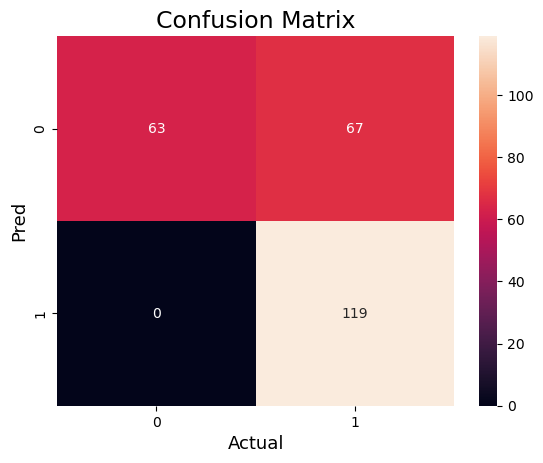

In [45]:
import seaborn as sns
sns.heatmap(cm.T,annot=True,
            fmt='g')
plt.ylabel('Pred',fontsize=13)
plt.xlabel('Actual',fontsize=13)
plt.title('Confusion Matrix',fontsize=17)
plt.show()